In [10]:
import os
import sys

sys.path.append(os.path.abspath(".."))


import torch
from torch.utils.data import TensorDataset, DataLoader
from src.models.Bayesian_LSTM import BayesianLSTM
from src.training.Bayesian_LSTM_trainer import predict

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = BayesianLSTM(
    n_features=5,
    hidden=32,
    num_layers=1,
    dense=16,
    dropout=0.1
).to(device)

x = torch.randn(4, 30, 5).to(device)

dataset = TensorDataset(x, torch.zeros(len(x)).to(device))
loader = DataLoader(dataset, batch_size=4)

predict(model, loader, device=device, T=100)

{'predictive_mean': array([0.12400863, 0.12776037, 0.13829193, 0.12998968], dtype=float32),
 'epistemic_uncertainty': array([0.00012775, 0.000216  , 0.00013012, 0.0002609 ], dtype=float32),
 'aleatoric_uncertainty': array([0.79305243, 0.79126716, 0.7849683 , 0.793357  ], dtype=float32),
 'total_uncertainty': array([0.79318017, 0.79148316, 0.78509843, 0.7936179 ], dtype=float32),
 'predictive_std': array([0.89060664, 0.8896534 , 0.8860578 , 0.89085233], dtype=float32),
 'y_true': array([0., 0., 0., 0.], dtype=float32)}

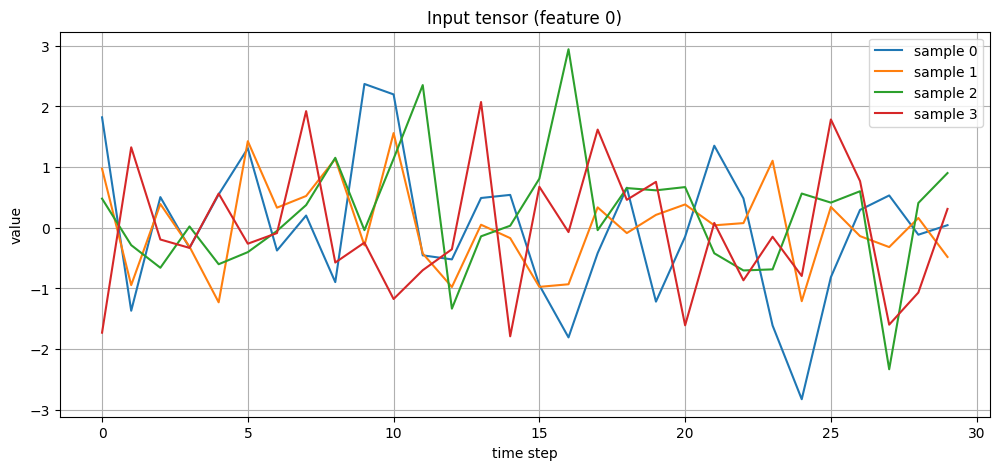

In [11]:
import matplotlib.pyplot as plt
import numpy as np

x_np = x.detach().cpu().numpy()

plt.figure(figsize=(12,5))

for i in range(x_np.shape[0]):
    plt.plot(x_np[i, :, 0], label=f'sample {i}')

plt.title("Input tensor (feature 0)")
plt.xlabel("time step")
plt.ylabel("value")
plt.legend()
plt.grid()
plt.show()

In [13]:
mu, logvar, std, _ = predict(model, loader, device=device, T=100)

plt.figure(figsize=(12,5))

plt.plot(mu, label="prediction mean")
plt.plot(std, label="uncertainty")
plt.title("Model output vs input structure")
plt.legend()
plt.grid()
plt.show()

ValueError: too many values to unpack (expected 4)

In [2]:
import os
import sys

sys.path.append(os.path.abspath(".."))
import numpy as np

from src.evaluation.metrics import (
    compute_rmse,
    compute_mae,
    compute_coverage,
    compute_coverage_at_levels,
    compute_nll,
    compute_crps,
    compute_sharpness,
    compute_probabilistic_metrics,
)


def run_manual_metrics_tests() -> None:
    print("\n=== TEST 1: caso base razonable ===")
    y_true = np.array([-4.0, -3.5, -4.2])
    mu = np.array([-3.9, -3.7, -4.1])
    sigma = np.array([0.2, 0.2, 0.3])

    rmse = compute_rmse(y_true, mu)
    mae = compute_mae(y_true, mu)
    coverage_95 = compute_coverage(y_true, mu, sigma, level=0.95)
    coverage_levels = compute_coverage_at_levels(y_true, mu, sigma, levels=(0.5, 0.8, 0.95))
    nll = compute_nll(y_true, mu, sigma)
    crps = compute_crps(y_true, mu, sigma)
    sharpness = compute_sharpness(sigma)

    print(f"RMSE: {rmse:.6f}")
    print(f"MAE: {mae:.6f}")
    print(f"Coverage 95%: {coverage_95:.6f}")
    print(f"Coverage at levels: {coverage_levels}")
    print(f"NLL: {nll:.6f}")
    print(f"CRPS: {crps:.6f}")
    print(f"Sharpness: {sharpness:.6f}")

    print("\n=== TEST 2: coverage sube si el intervalo es más ancho ===")
    sigma_narrow = np.array([0.05, 0.05, 0.05])
    sigma_wide = np.array([0.50, 0.50, 0.50])

    coverage_narrow = compute_coverage(y_true, mu, sigma_narrow, level=0.95)
    coverage_wide = compute_coverage(y_true, mu, sigma_wide, level=0.95)

    print(f"Coverage con sigma estrecha: {coverage_narrow:.6f}")
    print(f"Coverage con sigma amplia:   {coverage_wide:.6f}")

    assert coverage_wide >= coverage_narrow, "La coverage debería subir al ensanchar intervalos."

    print("\n=== TEST 3: sharpness empeora si ensanchas los intervalos ===")
    sharp_narrow = compute_sharpness(sigma_narrow)
    sharp_wide = compute_sharpness(sigma_wide)

    print(f"Sharpness con sigma estrecha: {sharp_narrow:.6f}")
    print(f"Sharpness con sigma amplia:   {sharp_wide:.6f}")

    assert sharp_wide > sharp_narrow, "La sharpness debería aumentar si sigma aumenta."

    print("\n=== TEST 4: NLL mejora cuando mu está más cerca de y_true ===")
    mu_bad = np.array([-3.0, -2.8, -3.1])
    mu_good = np.array([-4.0, -3.5, -4.2])
    sigma_same = np.array([0.2, 0.2, 0.2])

    nll_bad = compute_nll(y_true, mu_bad, sigma_same)
    nll_good = compute_nll(y_true, mu_good, sigma_same)

    print(f"NLL con mu mala:  {nll_bad:.6f}")
    print(f"NLL con mu buena: {nll_good:.6f}")

    assert nll_good < nll_bad, "La NLL debería bajar cuando mu se acerca a y_true."

    print("\n=== TEST 5: RMSE y MAE deben ser 0 si predicción perfecta ===")
    rmse_perfect = compute_rmse(y_true, y_true)
    mae_perfect = compute_mae(y_true, y_true)

    print(f"RMSE perfecta: {rmse_perfect:.6f}")
    print(f"MAE perfecta:  {mae_perfect:.6f}")

    assert np.isclose(rmse_perfect, 0.0), "RMSE debería ser 0 en predicción perfecta."
    assert np.isclose(mae_perfect, 0.0), "MAE debería ser 0 en predicción perfecta."

    print("\n=== TEST 6: prueba conjunta compute_probabilistic_metrics ===")
    all_metrics = compute_probabilistic_metrics(
        y_true=y_true,
        y_mean=mu,
        y_std=sigma,
        levels=(0.5, 0.8, 0.95),
    )

    for k, v in all_metrics.items():
        print(f"{k}: {v:.6f}" if isinstance(v, float) else f"{k}: {v}")

    expected_keys = {"rmse", "mae", "coverage", "nll", "crps", "sharpness", "coverage_50", "coverage_80", "coverage_95"}
    missing = expected_keys.difference(all_metrics.keys())
    assert not missing, f"Faltan claves en compute_probabilistic_metrics: {missing}"

    print("\n=== TEST 7: shape mismatch debe fallar ===")
    try:
        compute_rmse(np.array([1.0, 2.0]), np.array([1.0]))
        raise AssertionError("Debería haber fallado por shapes distintas.")
    except ValueError as e:
        print(f"OK, falló como debía: {e}")

    print("\n=== TEST 8: proteger sigma=0 o muy pequeña ===")
    sigma_tiny = np.array([0.0, 1e-12, 0.0])

    nll_tiny = compute_nll(y_true, mu, sigma_tiny)
    crps_tiny = compute_crps(y_true, mu, sigma_tiny)
    sharp_tiny = compute_sharpness(sigma_tiny)

    print(f"NLL con sigma tiny: {nll_tiny:.6f}")
    print(f"CRPS con sigma tiny: {crps_tiny:.6f}")
    print(f"Sharpness con sigma tiny: {sharp_tiny:.6f}")

    assert np.isfinite(nll_tiny), "NLL debería seguir siendo finita."
    assert np.isfinite(crps_tiny), "CRPS debería seguir siendo finita."
    assert np.isfinite(sharp_tiny), "Sharpness debería seguir siendo finita."

    print("\n✅ Todas las pruebas manuales han pasado.")


if __name__ == "__main__":
    run_manual_metrics_tests()


=== TEST 1: caso base razonable ===
RMSE: 0.141421
MAE: 0.133333
Coverage 95%: 1.000000
Coverage at levels: {'coverage_50': 0.6666666666666666, 'coverage_80': 1.0, 'coverage_95': 1.0}
NLL: -0.328492
CRPS: 0.090018
Sharpness: 0.233333

=== TEST 2: coverage sube si el intervalo es más ancho ===
Coverage con sigma estrecha: 0.000000
Coverage con sigma amplia:   1.000000

=== TEST 3: sharpness empeora si ensanchas los intervalos ===
Sharpness con sigma estrecha: 0.050000
Sharpness con sigma amplia:   0.500000

=== TEST 4: NLL mejora cuando mu está más cerca de y_true ===
NLL con mu mala:  10.559501
NLL con mu buena: -0.690499

=== TEST 5: RMSE y MAE deben ser 0 si predicción perfecta ===
RMSE perfecta: 0.000000
MAE perfecta:  0.000000

=== TEST 6: prueba conjunta compute_probabilistic_metrics ===
rmse: 0.141421
mae: 0.133333
coverage: 1.000000
nll: -0.328492
crps: 0.090018
sharpness: 0.233333
coverage_50: 0.666667
coverage_80: 1.000000
coverage_95: 1.000000

=== TEST 7: shape mismatch deb